 # **IMPORTAÇÃO DE BIBLIOTECA**


In [1]:
import pandas as pd

# **CRIAÇÃO DO PANDAS DATA FRAME**

In [2]:
dados = pd.read_csv("/content/SAMPLE_ENERGY_DATA.csv")

# **ANÁLISE EXPLORATÓRIA**

In [3]:
# Visualiar os registros
dados.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2008-12-01 00:00:00,2026-08-07 09:44:00,1.502,0.074,240.17,6.4,0,0,18
1,2006-12-17 00:00:00,2026-08-07 23:39:00,0.374,0.264,245.50,1.8,0,2,0
2,2009-06-03 00:00:00,2026-08-07 17:01:00,0.620,0.300,239.85,3.0,0,1,1
3,2007-05-09 00:00:00,2026-08-07 05:53:00,0.280,0.200,235.72,1.4,0,0,0
4,2008-12-14 00:00:00,2026-08-07 02:57:00,1.372,0.054,243.95,5.6,0,0,18


In [7]:
dados.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [4]:
# Dimensões do Data Frame
dados.shape

(163943, 9)

In [9]:
print(f'O total de registros é {dados.shape[0]}')

O total de registros é 163943


In [5]:
# Verificar as informações do formato dos dados de cada atributo (coluna)
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163943 entries, 0 to 163942
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   163943 non-null  object 
 1   Time                   163943 non-null  object 
 2   Global_active_power    163943 non-null  float64
 3   Global_reactive_power  163943 non-null  float64
 4   Voltage                163943 non-null  float64
 5   Global_intensity       163943 non-null  float64
 6   Sub_metering_1         163943 non-null  int64  
 7   Sub_metering_2         163943 non-null  int64  
 8   Sub_metering_3         163943 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 11.3+ MB


In [6]:
# Estatísticas descritivas dos atributos numéricos
# contagem, min, max, media, mediana, desvio padrão, distribuição dos quartis
dados.describe()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,163943.000000,163943.000000,163943.000000,163943.000000,163943.000000,163943.000000,163943.000000
mean,1.093051,0.124073,240.827630,4.633563,1.134236,1.315286,6.480124
std,1.062535,0.112305,3.242136,4.465014,6.202420,5.891517,8.454072
min,0.076000,0.000000,224.870000,0.200000,0.000000,0.000000,0.000000
25%,0.308000,0.048000,238.980000,1.400000,0.000000,0.000000,0.000000
50%,0.600000,0.100000,241.000000,2.600000,0.000000,0.000000,1.000000
75%,1.526000,0.196000,242.880000,6.400000,0.000000,1.000000,17.000000
max,10.290000,1.078000,253.750000,44.600000,83.000000,79.000000,31.000000


In [16]:
#Renomear os rótulos das colunas
#dados.rename
#Parâmetro: Dicionário que possui:
#Chaves ------> rótulos atuais
#Valores --------> rótulos desejados
#Axis ---------> 1(colunas)
#     ---------> 0(linhas)
dados = dados.rename({'Date':'Data',
                      'Time':'Hora',
                      'Global_active_power': 'Potencia_Ativa',
                      'Global_reactive_power': 'Potencia_Relativa',
                      'Voltage':'Tensao',
                      'Global_intensity':'Corrente',
                      'Sub_metering_1': 'Consumo_1',
                      'Sub_metering_2': 'Consumo_2',
                      'Sub_metering_3': 'Consumo_3'}, axis=1)

In [17]:
dados.columns

Index(['Data', 'Hora', 'Potencia_Ativa', 'Potencia_Relativa', 'Tensao',
       'Corrente', 'Consumo_1', 'Consumo_2', 'Consumo_3'],
      dtype='object')

In [19]:
#Criar um DataFrame 'DF1' a partir de 'dados' sem as colunas 'Data' e 'Hora'
# df1 = dados.drop(['Data', 'Hora, axis=1'])
df1 = dados.drop(columns = ["Data", "Hora"])
df1.head()

,Potencia_Ativa,Potencia_Relativa,Tensao,Corrente,Consumo_1,Consumo_2,Consumo_3
0,1.502,0.074,240.17,6.4,0,0,18
1,0.374,0.264,245.50,1.8,0,2,0
2,0.620,0.300,239.85,3.0,0,1,1
3,0.280,0.200,235.72,1.4,0,0,0
4,1.372,0.054,243.95,5.6,0,0,18


In [20]:
dados.columns

Index(['Data', 'Hora', 'Potencia_Ativa', 'Potencia_Relativa', 'Tensao',
       'Corrente', 'Consumo_1', 'Consumo_2', 'Consumo_3'],
      dtype='object')

In [24]:
# Array a partir de uma coluna
# Exemplo: coluna Corrente
# Pandas Series
corrente = dados['Corrente']
corrente

,Corrente
0,6.4
1,1.8
2,3.0
3,1.4
4,5.6
...,...
163938,3.6
163939,6.8
163940,1.2
163941,5.6


In [22]:
#Criar um DataFrame 'DF2' a partir de 'Dados' somente com as colunas Tensao, Corrente, Consumo, Consumo_2, Potencia_Relativa
# Pandas DataFrame
df2 = dados[['Tensao', 'Corrente', 'Consumo_2', 'Potencia_Relativa']]
df2.head()

,Tensao,Corrente,Consumo_2,Potencia_Relativa
0,240.17,6.4,0,0.074
1,245.50,1.8,2,0.264
2,239.85,3.0,1,0.300
3,235.72,1.4,0,0.200
4,243.95,5.6,0,0.054


In [26]:
#Criar um DataFrame 'DF3' a partir do DataFrame 'Dados' somente com as primeiras 4 colunas
# Metodos iloc e loc
# iloc -----> acesso por índice
# loc ------> acesso por rótulos
# Exemplo: .iloc[linhas, colunas]
# : -------> seleciona todos os registros(linhas)
# o:4 -------> seleciona da coluna 0 até a coluna anterior a 4 (a coluna 4 não é incluida)
df3 = dados.iloc[:,0:4]
df3.head()

,Data,Hora,Potencia_Ativa,Potencia_Relativa
0,2008-12-01 00:00:00,2026-08-07 09:44:00,1.502,0.074
1,2006-12-17 00:00:00,2026-08-07 23:39:00,0.374,0.264
2,2009-06-03 00:00:00,2026-08-07 17:01:00,0.620,0.300
3,2007-05-09 00:00:00,2026-08-07 05:53:00,0.280,0.200
4,2008-12-14 00:00:00,2026-08-07 02:57:00,1.372,0.054


In [28]:
# Qual é o valor maximo de demanda energética (Potência_Ativa) ? (PMAX)
PMAX = dados['Potencia_Ativa'].max()
print(f"O valor máximo de demanda energética é de: {PMAX:.2f} Kw")

O valor máximo de demanda energética é de: 10.29 Kw


In [29]:
# Qual é o limiar de 60% da demanda máxima ? (P60)
P60 = 0.6 * PMAX
print(f'O limiar de 60% é de {P60:.2f} Kw')

O limiar de 60% é de 6.17 Kw


In [30]:
# Criar um DataFrame 'DF4' a partir de dados somente com 'Data', 'Hora', 'Corrente' e 'Potencia Ativa'.
df4 = dados[['Data', 'Hora','Corrente', 'Potencia_Ativa']]
df4.head()

,Data,Hora,Corrente,Potencia_Ativa
0,2008-12-01 00:00:00,2026-08-07 09:44:00,6.4,1.502
1,2006-12-17 00:00:00,2026-08-07 23:39:00,1.8,0.374
2,2009-06-03 00:00:00,2026-08-07 17:01:00,3.0,0.620
3,2007-05-09 00:00:00,2026-08-07 05:53:00,1.4,0.280
4,2008-12-14 00:00:00,2026-08-07 02:57:00,5.6,1.372


In [31]:
df4.shape[0]

163943

In [33]:
# Criar um DataFrame 'DF5' a partir de 'DF4' somente com registros de consumidores que ultrapassaram o limiar de 60%
df5 = df4[df4['Potencia_Ativa'] > P60]
df5.head()

,Data,Hora,Corrente,Potencia_Ativa
296,2007-01-20 00:00:00,2026-08-07 19:19:00,27.2,6.240
581,2007-10-13 00:00:00,2026-08-07 20:12:00,30.2,6.888
1488,2008-07-12 00:00:00,2026-08-07 15:44:00,27.2,6.398
2453,2009-12-24 00:00:00,2026-08-07 23:00:00,26.6,6.406
2995,2008-09-04 00:00:00,2026-08-07 20:12:00,30.0,6.838


In [ ]:
# Quantos consumidores estão acima de P60 (60%) ?

In [36]:
print(f'Existem {df5.shape[0]} de consumidores acima de P60')

Existem 372 de consumidores acima de P60


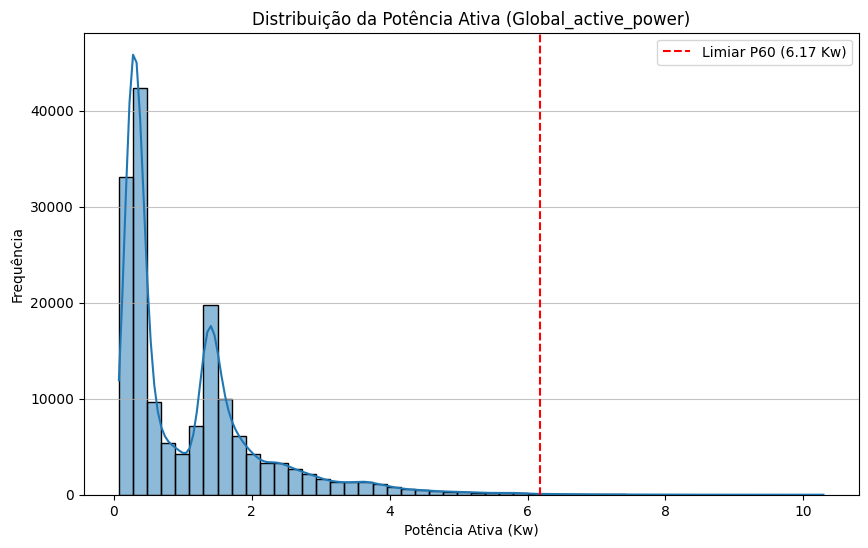

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(dados['Potencia_Ativa'], bins=50, kde=True)
plt.axvline(x=P60, color='r', linestyle='--', label=f'Limiar P60 ({P60:.2f} Kw)')
plt.title('Distribuição da Potência Ativa (Global_active_power)')
plt.xlabel('Potência Ativa (Kw)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

## Relatório sobre Consumidores Acima de P60

No seu conjunto de dados, existem 163.943 registros de consumo de energia. O valor máximo de 'Potencia_Ativa' registrado é de 10.29 Kw. O limiar de 60% dessa demanda máxima (P60) é de 6.17 Kw.

A análise mostrou que apenas 372 registros (`df5.shape[0]`) correspondem a consumidores que ultrapassaram o limiar de P60. Isso representa uma pequena fração dos registros totais (aproximadamente 0.23% dos dados).

**O motivo para essa baixa contagem pode ser explicado por alguns fatores, observáveis no histograma acima:**

1.  **Distribuição da Potência Ativa:** O histograma da 'Potencia_Ativa' provavelmente mostra uma distribuição que tende a ter a maioria dos valores concentrada em níveis de potência mais baixos. É comum em dados de consumo de energia que a maior parte do tempo o consumo seja moderado, com picos de alta demanda ocorrendo com menos frequência.

2.  **Picos de Consumo Raros:** Os valores de 'Potencia_Ativa' acima de P60 (6.17 Kw) representam situações de consumo muito elevado, que geralmente são eventos pontuais ou raros. Por exemplo, podem ser períodos de uso intensivo de vários aparelhos ao mesmo tempo ou ocorrências anômalas.

3.  **Natureza do Conjunto de Dados:** Se o conjunto de dados representa um período prolongado (como anos), é natural que a ocorrência de picos de demanda seja infrequente em comparação com o volume total de registros diários/horários.

Em resumo, a pequena quantidade de registros acima do P60 indica que o consumo de energia em níveis muito altos é um evento atípico ou esporádico na sua base de dados, com a maioria dos registros caindo em faixas de consumo mais habituais.